# requirements for plotting


In [13]:
import wandb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [14]:
import wandb
import pandas as pd
from datetime import datetime

# Initialize the API
api = wandb.Api()

# Parse your project URL - format is https://wandb.ai/ENTITY/PROJECT
entity = "neuroneural"
project_name = "holographic_project"

# Get all runs from the project
runs = api.runs(f"{entity}/{project_name}")

print(f"Found {len(runs)} runs in the project")

# Example 4: Get specific runs by filters
# Filter runs by tags, state, or config values

# time_threshold = datetime(2026, 1, 28, 1, 50, 0).isoformat() + 'Z'

filtered_runs = api.runs(
    f"{entity}/{project_name}",
    filters={
        "state": "finished",  # Only finished runs
        # "user": "pavalipopov",
        # "tags": {"$in": ["baseline"]},  # Runs with 'baseline' tag
        # "config.learning_rate": 0.001  # Runs with specific config
    }
)


len(filtered_runs)

Found 144 runs in the project


140

In [36]:
data = []
for run in filtered_runs:
    summ = json.loads(run.summary._json_dict)
    config = json.loads(run.config)
    if config['experiment']['value']["databases"] != "MindfulTensors":
        continue

    dataset = config['experiment']['value']["collections"]
    model = config["model"]['value']["model_label"]
    labels = config["experiment"]["value"]["metafields"]
    labels = '_'.join(labels)
    modalities = config["experiment"]["value"]["dbfields"]
    modalities = '_'.join(modalities)
    try:
        masked = config["model"]["value"]["masked"]
        sparsity = config["model"]["value"]["sparsity"]
        flag = config["experiment"]["value"]["cv_seed"]
    except:
        continue
    fold_idx = config["fold_idx"]["value"]

    

    history_df = run.history()
    try:
        history_df = history_df[["accuracy_epoch/infer", "auc_epoch/infer", "loss_epoch/infer"]]
        # history_df.dropna()
        # find min validation loss index, then accuracy and auc
        min_idx = history_df["loss_epoch/infer"].idxmin()
        acc = history_df.loc[min_idx]["accuracy_epoch/infer"]
        auc = history_df.loc[min_idx]["auc_epoch/infer"]
    except Exception as e:
        print(f"Error processing run {run.id}: {e}")
        continue


    data.append(
        {
            "Dataset": dataset,
            "Model": model,
            "Masked": masked,
            "Sparsity": sparsity,
            "Modalities": modalities,
            "Labels": labels,
            "Fold": fold_idx,
            "Accuracy": acc,
            "AUC": auc
        }
    )

data_df = pd.DataFrame(data)
data_df

,Dataset,Model,Masked,Sparsity,Modalities,Labels,Fold,Accuracy,AUC
0,fbirn,_resnet3d_gender_64base,False,0.7,dwi,gender_encoded,0,0.707108,0.537356
1,fbirn,_resnet3d_gender_64base,False,0.7,dwi,gender_encoded,1,0.837010,0.876437
2,fbirn,_resnet3d_gender_64base,False,0.7,dwi,gender_encoded,2,0.778186,0.434028
3,fbirn,_resnet3d_gender_64base,False,0.7,dwi,gender_encoded,3,0.736520,0.445455
4,fbirn,_resnet3d_gender_64base,False,0.7,dwi,gender_encoded,4,0.812500,0.583333
...,...,...,...,...,...,...,...,...,...
75,fbirn,_resnet3d_gender_64base,True,0.7,falff,gender_encoded,5,0.750000,0.826923
76,fbirn,_resnet3d_gender_64base,True,0.7,falff,gender_encoded,6,0.742857,0.491453
77,fbirn,_resnet3d_gender_64base,True,0.7,falff,gender_encoded,7,0.828571,0.833333
78,fbirn,_resnet3d_gender_64base,True,0.7,falff,gender_encoded,8,0.742857,0.790598


In [37]:
len(data_df)

80

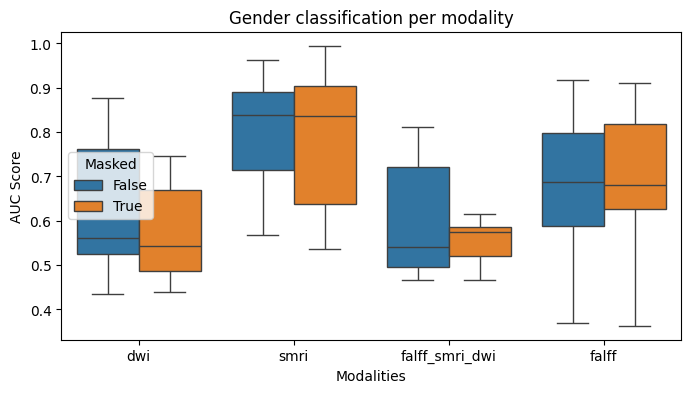

In [40]:
# plot AUC scores per modality as boxplots
plt.figure(figsize=(8, 4))
sns.boxplot(x="Modalities", y="AUC", hue="Masked", data=data_df, showfliers=False)
plt.title("Gender classification per modality")
plt.ylabel("AUC Score")
plt.xlabel("Modalities")
# plt.legend(title="Model")
plt.show()